In [1]:
import os
os.environ["KAGGLE_USERNAME"] = "manu62"
os.environ["KAGGLE_KEY"] = "a3b2b4ae1f9285cd87a9ac0069d8ecd0"

Device: cuda


100%|██████████| 200M/200M [00:05<00:00, 38.4MB/s]

Extracting files...


Detected Normal Label: Normal Traffic

Binary Distribution:
BinaryLabel
0    249337
1     50662
Name: count, dtype: int64
Epoch 1/20 | Train 184.32 | Val 23.00
Epoch 2/20 | Train 116.67 | Val 18.67
Epoch 3/20 | Train 100.25 | Val 17.02
Epoch 4/20 | Train 93.04 | Val 16.65
Epoch 5/20 | Train 87.60 | Val 15.13
Epoch 6/20 | Train 83.54 | Val 14.50
Epoch 7/20 | Train 80.62 | Val 14.28
Epoch 8/20 | Train 78.65 | Val 14.32
Epoch 9/20 | Train 77.42 | Val 14.08
Epoch 10/20 | Train 76.56 | Val 13.43
Epoch 11/20 | Train 75.93 | Val 13.36
Epoch 12/20 | Train 75.37 | Val 13.42
Epoch 13/20 | Train 74.62 | Val 13.25
Epoch 14/20 | Train 73.55 | Val 13.39
Epoch 15/20 | Train 73.49 | Val 13.02
Epoch 16/20 | Train 72.58 | Val 13.05
Epoch 17/20 | Train 71.69 | Val 12.78
Epoch 18/20 | Train 71.39 | Val 12.73
Epoch 19/20 | Train 70.79 | Val 12.70
Epoch 20/20 | Train 70.28 | Val 12.72

Accuracy: 0.9724666666666667
F1: 0.922904610789621
MCC: 0.9081909226606908
AUC: 0.9961909741317905

Classification Report:


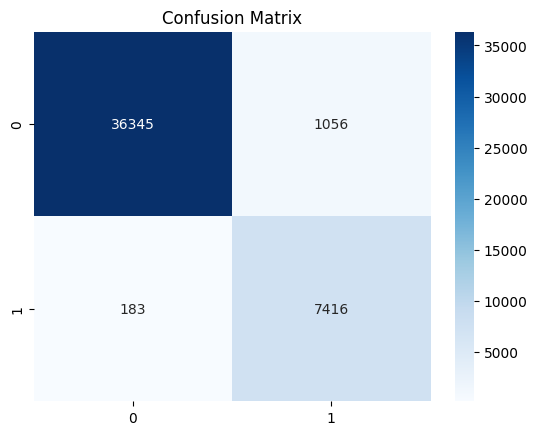

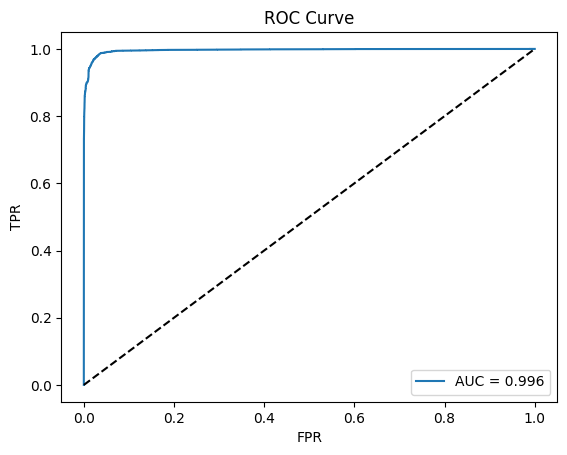


Hardware Profiling
Parameters: 318,083
FLOPs: 16,430,848.0


In [2]:
# ================================================================
# PG-NET BINARY IDS (Publication-Ready Version)
# ================================================================

!pip install -q performer-pytorch thop kagglehub

import os, warnings, time, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, roc_auc_score,
                             matthews_corrcoef,
                             confusion_matrix, roc_curve)
from performer_pytorch import SelfAttention
from thop import profile
import kagglehub
from collections import Counter

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================================================================
# CONFIG
# ================================================================
CFG = {
    "max_samples": 300000,
    "batch_size": 512,
    "epochs": 20,
    "lr": 5e-5,
    "label_smoothing": 0.03,
    "grad_clip": 0.5,
    "early_stop_patience": 5,
    "d_model": 64,
    "nb_features": 32,
}

# ================================================================
# LOAD DATA
# ================================================================
def load_dataset():
    path = kagglehub.dataset_download(
        "ericanacletoribeiro/cicids2017-cleaned-and-preprocessed"
    )
    df = pd.read_csv(os.path.join(path, "cicids2017_cleaned.csv"))
    df.columns = df.columns.str.strip()
    return df

# ================================================================
# PREPARE BINARY DATA
# ================================================================
def prepare_binary(df):

    label_col = "Attack Type"

    # Auto detect normal label
    normal_label = df[label_col].value_counts().idxmax()
    print("Detected Normal Label:", normal_label)

    df["BinaryLabel"] = (df[label_col] != normal_label).astype(int)

    # Stratified sampling (300k)
    if len(df) > CFG["max_samples"]:
        df = df.groupby("BinaryLabel", group_keys=False).apply(
            lambda x: x.sample(
                int(CFG["max_samples"] * len(x) / len(df)),
                random_state=42
            )
        )

    print("\nBinary Distribution:")
    print(df["BinaryLabel"].value_counts())

    X = df.drop(columns=["Attack Type", "BinaryLabel"]).values.astype(np.float32)
    y = df["BinaryLabel"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.15,
        stratify=y_train, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test

# ================================================================
# DATASET
# ================================================================
class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# ================================================================
# MODEL
# ================================================================
class PerformerBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = SelfAttention(dim=d, heads=4,
                                  nb_features=CFG["nb_features"],
                                  causal=False)
        self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(
            nn.Linear(d, d*2),
            nn.GELU(),
            nn.Linear(d*2, d)
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class PGNetBinary(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        d = CFG["d_model"]

        self.proj = nn.Linear(1, d)
        self.pos = nn.Parameter(torch.randn(1, n_features, d) * 0.02)

        self.block1 = PerformerBlock(d)
        self.block2 = PerformerBlock(d)

        self.gru = nn.GRU(d, 128, batch_first=True, bidirectional=True)

        self.pool = nn.Linear(256, 1)
        self.classifier = nn.Linear(256, 2)

    def forward(self, x):
        x = self.proj(x.unsqueeze(-1))
        x = x + self.pos[:, :x.size(1), :]
        x = self.block1(x)
        x = self.block2(x)
        x, _ = self.gru(x)
        weights = torch.softmax(self.pool(x), dim=1)
        x = (weights * x).sum(dim=1)
        return self.classifier(x)

# ================================================================
# TRAINING
# ================================================================
def train_model(model, train_loader, val_loader, y_train):

    counts = Counter(y_train)
    total = len(y_train)

    # √-smoothed inverse frequency
    raw_weights = [total / (2 * counts[i]) for i in range(2)]
    weights = torch.tensor([np.sqrt(w) for w in raw_weights],
                           dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=CFG["label_smoothing"]
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"]
    )

    best_val = float("inf")
    patience = 0

    for epoch in range(CFG["epochs"]):

        model.train()
        train_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),
                                           CFG["grad_clip"])
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item()

        scheduler.step()

        print(f"Epoch {epoch+1}/{CFG['epochs']} | "
              f"Train {train_loss:.2f} | Val {val_loss:.2f}")

        if val_loss < best_val:
            best_val = val_loss
            patience = 0
            torch.save(model.state_dict(), "best_binary.pt")
        else:
            patience += 1

        if patience >= CFG["early_stop_patience"]:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load("best_binary.pt"))
    return model

# ================================================================
# EVALUATION + PROFILING
# ================================================================
def evaluate(model, loader):

    model.eval()
    preds, labels, probs = [], [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            outputs = model(Xb)
            p = torch.softmax(outputs, dim=1)

            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            probs.extend(p[:,1].cpu().numpy())
            labels.extend(yb.numpy())

    print("\nAccuracy:", accuracy_score(labels, preds))
    print("F1:", f1_score(labels, preds))
    print("MCC:", matthews_corrcoef(labels, preds))
    print("AUC:", roc_auc_score(labels, probs))

    print("\nClassification Report:\n")
    print(classification_report(labels, preds))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, probs)
    plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(labels, probs))
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Hardware profiling
    print("\nHardware Profiling")
    total_params = sum(p.numel() for p in model.parameters())
    print("Parameters:", f"{total_params:,}")

    dummy = torch.randn(1, X_train.shape[1]).to(device)
    flops, _ = profile(model, inputs=(dummy,), verbose=False)
    print("FLOPs:", f"{flops:,}")

# ================================================================
# MAIN
# ================================================================
df = load_dataset()
X_train, X_val, X_test, y_train, y_val, y_test = prepare_binary(df)

train_loader = DataLoader(FlowDataset(X_train, y_train),
                          batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(FlowDataset(X_val, y_val),
                        batch_size=CFG["batch_size"])
test_loader = DataLoader(FlowDataset(X_test, y_test),
                         batch_size=CFG["batch_size"])

model = PGNetBinary(X_train.shape[1]).to(device)

model = train_model(model, train_loader, val_loader, y_train)

evaluate(model, test_loader)

Device: cuda
Using Colab cache for faster access to the 'cicids2017-cleaned-and-preprocessed' dataset.

Balanced Distribution:
Attack Type
DoS               193745
Normal Traffic    150000
DDoS              128014
Port Scanning      90694
Brute Force         9150
Web Attacks         2143
Bots                1948
Name: count, dtype: int64

Smoothed Class Weights:
Class 0: 6.496
Class 1: 2.998
Class 2: 0.802
Class 3: 0.652
Class 4: 0.740
Class 5: 0.952
Class 6: 6.196
Epoch 1/25 | Train 1062.99 | Val 138.53
Epoch 2/25 | Train 716.79 | Val 118.05
Epoch 3/25 | Train 645.29 | Val 112.15
Epoch 4/25 | Train 645.79 | Val 110.95
Epoch 5/25 | Train 623.12 | Val 112.44
Epoch 6/25 | Train 643.90 | Val 113.48
Epoch 7/25 | Train 620.42 | Val 108.58
Epoch 8/25 | Train 611.93 | Val 107.22
Epoch 9/25 | Train 604.21 | Val 107.78
Epoch 10/25 | Train 597.68 | Val 105.05
Epoch 11/25 | Train 586.83 | Val 104.42
Epoch 12/25 | Train 583.16 | Val 102.96
Epoch 13/25 | Train 581.45 | Val 102.45
Epoch 14/25 | Trai

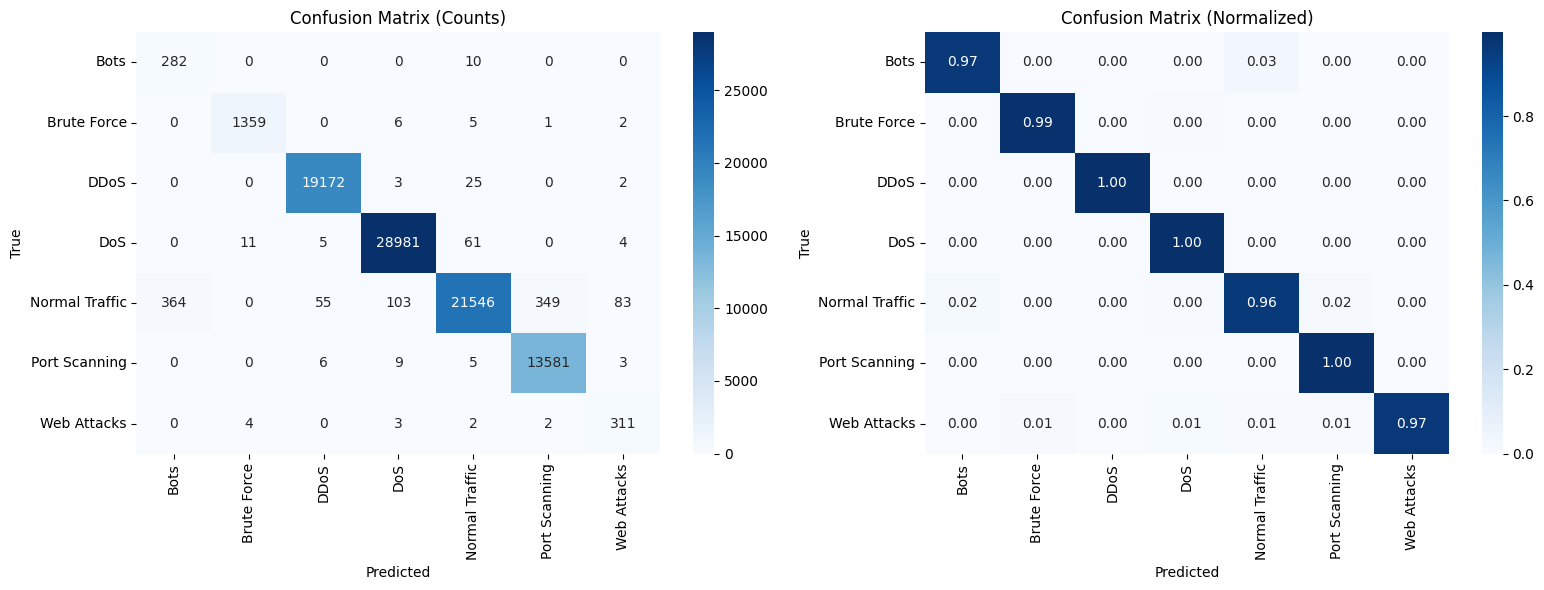

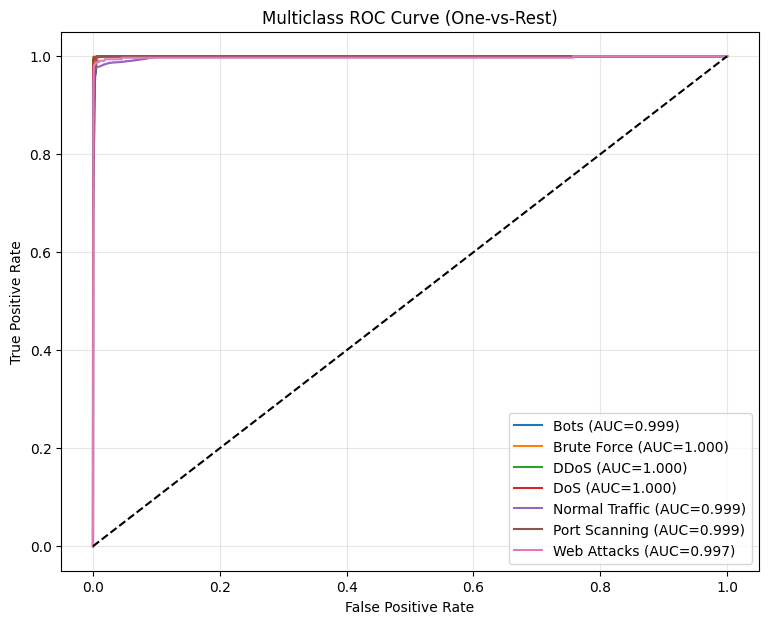


================ HARDWARE PROFILE ================
Total Parameters: 319,368
FLOPs: 16,432,128.0
GPU Memory Usage (MB): 39.74

Batch Size: 1
Latency: 4.53 ms
Throughput: 221 samples/sec

Batch Size: 32
Latency: 6.56 ms
Throughput: 4875 samples/sec

Batch Size: 256
Latency: 11.72 ms
Throughput: 21837 samples/sec



In [3]:
# ================================================================
# PG-Net FINAL MULTICLASS IDS
# Corrected Weight-Balanced Version (Stable & Publication-Ready)
# ================================================================

!pip install -q performer-pytorch thop kagglehub

import os, warnings, time, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, auc)
from performer_pytorch import SelfAttention
from thop import profile
import kagglehub
from collections import Counter

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================================================================
# CONFIG
# ================================================================
CFG = {
    "majority_cap": 150000,
    "batch_size": 512,
    "epochs": 25,
    "lr": 7e-5,
    "label_smoothing": 0.05,
    "grad_clip": 0.5,
    "early_stop_patience": 5,
    "d_model": 64,
    "nb_features": 32,
}

# ================================================================
# LOAD DATA
# ================================================================
def load_dataset():
    path = kagglehub.dataset_download(
        "ericanacletoribeiro/cicids2017-cleaned-and-preprocessed"
    )
    df = pd.read_csv(os.path.join(path, "cicids2017_cleaned.csv"))
    df.columns = df.columns.str.strip()
    return df

# ================================================================
# CONTROLLED BALANCING
# ================================================================
def controlled_balance(df, label_col):
    counts = df[label_col].value_counts()
    majority = counts.idxmax()
    frames = []

    for cls, group in df.groupby(label_col):
        if cls == majority:
            group = group.sample(
                n=min(len(group), CFG["majority_cap"]),
                random_state=42
            )
        frames.append(group)

    df_balanced = pd.concat(frames).sample(frac=1, random_state=42)
    print("\nBalanced Distribution:")
    print(df_balanced[label_col].value_counts())
    return df_balanced.reset_index(drop=True)

# ================================================================
# DATA PREP
# ================================================================
def prepare_data(df, label_col):

    le = LabelEncoder()
    y = le.fit_transform(df[label_col])
    X = df.drop(columns=[label_col]).values.astype(np.float32)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.15,
        stratify=y_train, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, le

# ================================================================
# DATASET
# ================================================================
class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# ================================================================
# MODEL
# ================================================================
class PerformerBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = SelfAttention(
            dim=d,
            heads=4,
            nb_features=CFG["nb_features"],
            causal=False
        )
        self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(
            nn.Linear(d, d*2),
            nn.GELU(),
            nn.Linear(d*2, d)
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class PGNet(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        d = CFG["d_model"]

        self.proj = nn.Linear(1, d)
        self.pos = nn.Parameter(torch.randn(1, n_features, d) * 0.02)

        self.block1 = PerformerBlock(d)
        self.block2 = PerformerBlock(d)

        self.gru = nn.GRU(d, 128, batch_first=True, bidirectional=True)

        self.pool = nn.Linear(256, 1)
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.proj(x.unsqueeze(-1))
        x = x + self.pos[:, :x.size(1), :]
        x = self.block1(x)
        x = self.block2(x)
        x, _ = self.gru(x)
        weights = torch.softmax(self.pool(x), dim=1)
        x = (weights * x).sum(dim=1)
        return self.classifier(x)

# ================================================================
# TRAINING (SMOOTHED WEIGHTS)
# ================================================================
def train_model(model, train_loader, val_loader, y_train):

    counts = Counter(y_train)
    total = len(y_train)
    num_classes = len(counts)

    # √-smoothed inverse frequency
    raw_weights = [
        total / (num_classes * counts[i])
        for i in range(num_classes)
    ]

    weights = [np.sqrt(w) for w in raw_weights]
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    print("\nSmoothed Class Weights:")
    for i, w in enumerate(weights):
        print(f"Class {i}: {w.item():.3f}")

    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=CFG["label_smoothing"]
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"]
    )

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(CFG["epochs"]):

        model.train()
        train_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(Xb)
            loss = criterion(outputs, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),
                                           CFG["grad_clip"])
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item()

        scheduler.step()

        print(f"Epoch {epoch+1}/{CFG['epochs']} | "
              f"Train {train_loss:.2f} | Val {val_loss:.2f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1

        if patience_counter >= CFG["early_stop_patience"]:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load("best_model.pt"))
    return model

# ================================================================
# MAIN
# ================================================================
df = load_dataset()
df = controlled_balance(df, "Attack Type")

X_train, X_val, X_test, y_train, y_val, y_test, le = prepare_data(df, "Attack Type")

train_loader = DataLoader(FlowDataset(X_train, y_train),
                          batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(FlowDataset(X_val, y_val),
                        batch_size=CFG["batch_size"])
test_loader = DataLoader(FlowDataset(X_test, y_test),
                         batch_size=CFG["batch_size"])

model = PGNet(X_train.shape[1], len(le.classes_)).to(device)

model = train_model(model, train_loader, val_loader, y_train)

print("\nTraining Complete.")
# ================================================================
# PG-Net FINAL MULTICLASS IDS
# Corrected Weight-Balanced Version (Stable & Publication-Ready)
# ================================================================

!pip install -q performer-pytorch thop kagglehub

import os, warnings, time, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, auc)
from performer_pytorch import SelfAttention
from thop import profile
import kagglehub
from collections import Counter

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================================================================
# CONFIG
# ================================================================
CFG = {
    "majority_cap": 150000,
    "batch_size": 512,
    "epochs": 25,
    "lr": 7e-5,
    "label_smoothing": 0.05,
    "grad_clip": 0.5,
    "early_stop_patience": 5,
    "d_model": 64,
    "nb_features": 32,
}

# ================================================================
# LOAD DATA
# ================================================================
def load_dataset():
    path = kagglehub.dataset_download(
        "ericanacletoribeiro/cicids2017-cleaned-and-preprocessed"
    )
    df = pd.read_csv(os.path.join(path, "cicids2017_cleaned.csv"))
    df.columns = df.columns.str.strip()
    return df

# ================================================================
# CONTROLLED BALANCING
# ================================================================
def controlled_balance(df, label_col):
    counts = df[label_col].value_counts()
    majority = counts.idxmax()
    frames = []

    for cls, group in df.groupby(label_col):
        if cls == majority:
            group = group.sample(
                n=min(len(group), CFG["majority_cap"]),
                random_state=42
            )
        frames.append(group)

    df_balanced = pd.concat(frames).sample(frac=1, random_state=42)
    print("\nBalanced Distribution:")
    print(df_balanced[label_col].value_counts())
    return df_balanced.reset_index(drop=True)

# ================================================================
# DATA PREP
# ================================================================
def prepare_data(df, label_col):

    le = LabelEncoder()
    y = le.fit_transform(df[label_col])
    X = df.drop(columns=[label_col]).values.astype(np.float32)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.15,
        stratify=y_train, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, le

# ================================================================
# DATASET
# ================================================================
class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# ================================================================
# MODEL
# ================================================================
class PerformerBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = SelfAttention(
            dim=d,
            heads=4,
            nb_features=CFG["nb_features"],
            causal=False
        )
        self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(
            nn.Linear(d, d*2),
            nn.GELU(),
            nn.Linear(d*2, d)
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class PGNet(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        d = CFG["d_model"]

        self.proj = nn.Linear(1, d)
        self.pos = nn.Parameter(torch.randn(1, n_features, d) * 0.02)

        self.block1 = PerformerBlock(d)
        self.block2 = PerformerBlock(d)

        self.gru = nn.GRU(d, 128, batch_first=True, bidirectional=True)

        self.pool = nn.Linear(256, 1)
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.proj(x.unsqueeze(-1))
        x = x + self.pos[:, :x.size(1), :]
        x = self.block1(x)
        x = self.block2(x)
        x, _ = self.gru(x)
        weights = torch.softmax(self.pool(x), dim=1)
        x = (weights * x).sum(dim=1)
        return self.classifier(x)

# ================================================================
# TRAINING (SMOOTHED WEIGHTS)
# ================================================================
def train_model(model, train_loader, val_loader, y_train):

    counts = Counter(y_train)
    total = len(y_train)
    num_classes = len(counts)

    # √-smoothed inverse frequency
    raw_weights = [
        total / (num_classes * counts[i])
        for i in range(num_classes)
    ]

    weights = [np.sqrt(w) for w in raw_weights]
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    print("\nSmoothed Class Weights:")
    for i, w in enumerate(weights):
        print(f"Class {i}: {w.item():.3f}")

    criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=CFG["label_smoothing"]
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"]
    )

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(CFG["epochs"]):

        model.train()
        train_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(Xb)
            loss = criterion(outputs, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),
                                           CFG["grad_clip"])
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item()

        scheduler.step()

        print(f"Epoch {epoch+1}/{CFG['epochs']} | "
              f"Train {train_loss:.2f} | Val {val_loss:.2f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            patience_counter += 1

        if patience_counter >= CFG["early_stop_patience"]:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load("best_model.pt"))
    return model

# ================================================================
# MAIN
# ================================================================
df = load_dataset()
df = controlled_balance(df, "Attack Type")

X_train, X_val, X_test, y_train, y_val, y_test, le = prepare_data(df, "Attack Type")

train_loader = DataLoader(FlowDataset(X_train, y_train),
                          batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(FlowDataset(X_val, y_val),
                        batch_size=CFG["batch_size"])
test_loader = DataLoader(FlowDataset(X_test, y_test),
                         batch_size=CFG["batch_size"])

model = PGNet(X_train.shape[1], len(le.classes_)).to(device)

model = train_model(model, train_loader, val_loader, y_train)

print("\nTraining Complete.")
# ================================================================
# EVALUATION + PROFILING BLOCK
# ================================================================

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from thop import profile
import numpy as np
import time

# ================================================================
# PREDICTION
# ================================================================
def get_predictions(model, loader):
    model.eval()
    preds, labels, probs = [], [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            outputs = model(Xb)
            probabilities = torch.softmax(outputs, dim=1)

            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            probs.append(probabilities.cpu().numpy())
            labels.extend(yb.numpy())

    probs = np.vstack(probs)
    return np.array(labels), np.array(preds), probs


# ================================================================
# CONFUSION MATRIX
# ================================================================
def plot_confusion(labels, preds, class_names):

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1,2, figsize=(16,6))

    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues", ax=axes[1])
    axes[1].set_title("Confusion Matrix (Normalized)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.show()


# ================================================================
# MULTICLASS ROC
# ================================================================
def plot_multiclass_roc(labels, probs, class_names):

    n_classes = len(class_names)
    y_bin = label_binarize(labels, classes=list(range(n_classes)))

    plt.figure(figsize=(9,7))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr,
                 label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curve (One-vs-Rest)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# ================================================================
# HARDWARE PROFILING
# ================================================================
def hardware_profile(model, input_dim):

    print("\n================ HARDWARE PROFILE ================")

    # Parameters
    total_params = sum(p.numel() for p in model.parameters())
    print("Total Parameters:", f"{total_params:,}")

    # FLOPs
    dummy = torch.randn(1, input_dim).to(device)
    flops, _ = profile(model, inputs=(dummy,), verbose=False)
    print("FLOPs:", f"{flops:,}")

    # GPU Memory
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        _ = model(dummy)
        mem = torch.cuda.max_memory_allocated() / 1e6
        print("GPU Memory Usage (MB):", round(mem,2))

    # Latency + Throughput
    for bs in [1, 32, 256]:

        dummy = torch.randn(bs, input_dim).to(device)

        # Warmup
        for _ in range(20):
            _ = model(dummy)

        torch.cuda.synchronize()
        start = time.time()

        for _ in range(100):
            _ = model(dummy)

        torch.cuda.synchronize()
        latency = (time.time() - start) / 100

        print(f"\nBatch Size: {bs}")
        print(f"Latency: {latency*1000:.2f} ms")
        print(f"Throughput: {bs/latency:.0f} samples/sec")

    print("==================================================\n")


# ================================================================
# RUN FULL EVALUATION
# ================================================================

labels, preds, probs = get_predictions(model, test_loader)

print("\nAccuracy:", accuracy_score(labels, preds))
print("Macro F1:", f1_score(labels, preds, average="macro"))
print("MCC:", matthews_corrcoef(labels, preds))

print("\nClassification Report:\n")
print(classification_report(labels, preds,
                            target_names=le.classes_))

plot_confusion(labels, preds, le.classes_)
plot_multiclass_roc(labels, probs, le.classes_)
hardware_profile(model, X_train.shape[1])